# Projeto - Engine de Xadrez
### Daniel Couto

Este projeto pretende desenvolver, testar e comparar diferentes arquiteturas e heurísticas para uma rede neural jogar xadrez. Usarei o dataset  

**Objetivos.**
- construir uma engine que avalie e sugira o melhor lance;
- comparar arquiteturas simples e profundas;
- investigar o efeito de escolhas de treinamento;
- analisar erros e limitações do modelo;
- contruir uma rede para explicar o porquê do lance.

**Métodos gerais.**
- Usarei a biblioteca python-chess para tratar com mais domínio dos dados.
- Registre as escolhas principais de hiperparâmetros.
- Quando o enunciado pedir comparação, use evidências dos seus resultados.
- Não apague as células do enunciado.
- Use o conjunto de **teste** apenas na etapa final.



### Configurações inicias

In [1]:
# !pip install scikit-learn
# !pip install chess


In [2]:
import chess
import random
import numpy as np
from pathlib import Path
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch.optim as optim
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm


seed = 1981
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Semente: {seed}")
print(f"Dispositivo: {device}")
print("Versão do Torch:", torch.__version__)
print("Versão do Torchvision:", torchvision.__version__)

student_run_tag = "DCP"
output_dir = Path("assignment1_outputs")
output_dir.mkdir(exist_ok=True)
(output_dir / student_run_tag).mkdir(exist_ok=True)
print("Diretório de saída:", output_dir / student_run_tag)

Semente: 1981
Dispositivo: cuda
Versão do Torch: 2.11.0+cu128
Versão do Torchvision: 0.26.0+cu128
Diretório de saída: assignment1_outputs/DCP


/home/al.daniel.pereira/Downloads/git_curso/ml2_trabalhos_2026/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Modelo de Avaliação - Engine

Aqui vou construir um modelo capaz de avaliar uma posição de xadrez, e userei uma MCTS para a escolha de melhor lance. Treinarei o modelo em um dataset com posições de xadrez e a correspondente avaliação em centipawns pelo StockFish.

### 1. Importação da Dataset e Análise Exploratória

In [3]:
df = pd.read_csv('chessData.csv')
print(df.head())
print(f"Tamanho do dataset: {len(df):.2f}")

                                                 FEN Evaluation
0  rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...        -10
1  rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...        +56
2  rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...         -9
3  rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPP2PPP/RNBQKB...        +52
4  rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPPN1PPP/R1BQK...        -26
Tamanho do dataset: 12958035.00


#### 1.1 Coluna 'Evaluation'

Para tirar informação da coluna de avaliação, como média e desvio padrão, primeiro precisamos transformá-la em float e também tirar as avaliações que "anuciam mate" no formato '#3' , por exemplo, pois ficaria intratável na análise. 

In [4]:
df['Evaluation_clean'] = df['Evaluation'].str.replace('+', '', regex=False)

df = df[~df['Evaluation_clean'].str.contains('#')]

df['Evaluation_clean'] = df['Evaluation_clean'].astype(float)

media_eval = df['Evaluation_clean'].mean()
std_eval = df['Evaluation_clean'].std()

print(f"Estatísticas da Avaliação (Centipawns)")
print(f"Média: {media_eval:.2f}")
print(f"Desvio Padrão: {std_eval:.2f}")
print(f"Total de posições sem mate próximo analisadas: {len(df['Evaluation_clean'])}")

Estatísticas da Avaliação (Centipawns)
Média: 45.51
Desvio Padrão: 813.89
Total de posições sem mate próximo analisadas: 12767881


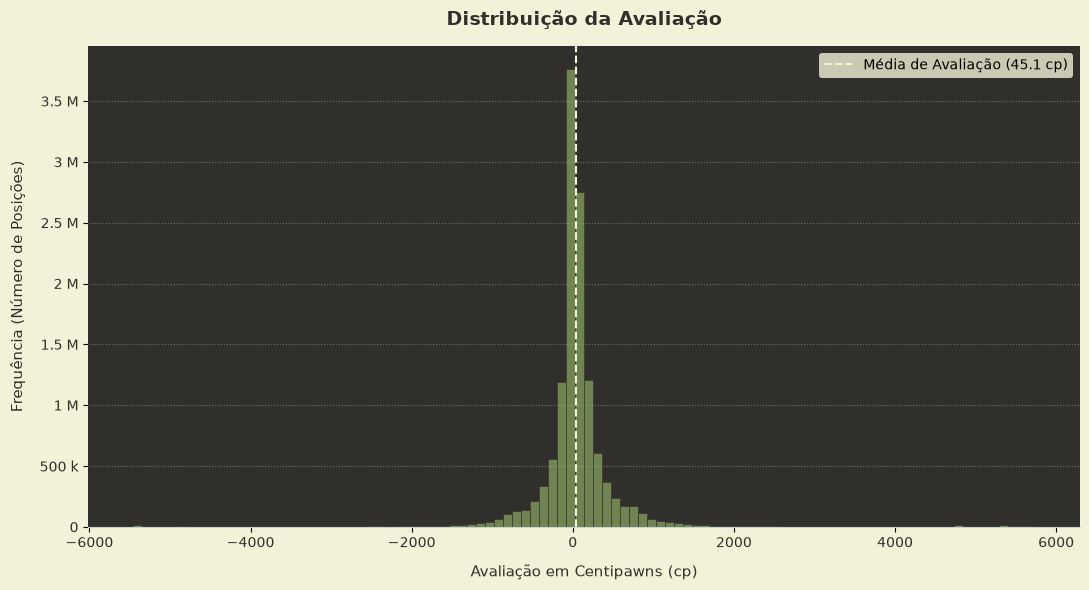

In [ ]:
import matplotlib.ticker as ticker

# Filtrando os outliers usando os percentis 5% e 95%
q_low = df['Evaluation_clean'].quantile(0.005)
q_high = df['Evaluation_clean'].quantile(0.995)
df_filtrado = df[(df['Evaluation_clean'] >= q_low) & (df['Evaluation_clean'] <= q_high)]

fig, ax = plt.subplots(figsize=(11, 6))
                                
COR_FUNDO_EXTERNO = '#F1F2D8' 
COR_FUNDO_INTERNO = '#312F2B' 

fig.patch.set_facecolor(COR_FUNDO_EXTERNO) 
ax.set_facecolor(COR_FUNDO_INTERNO)        

n, bins, patches = ax.hist(
    df_filtrado['Evaluation_clean'], 
    bins=100, 
    edgecolor=COR_FUNDO_INTERNO, 
    linewidth=0.5,
    alpha=0.85, 
    color='#7B9459'
)

media_eval = df_filtrado['Evaluation_clean'].mean()

ax.axvline(
    media_eval, 
    color='#F1F2D8', 
    linestyle='--', 
    linewidth=1.5, 
    label=f'Média de Avaliação ({media_eval:.1f} cp)' 
)

ax.set_title('Distribuição da Avaliação', fontsize=14, fontweight='bold', pad=15, color=COR_FUNDO_INTERNO)
ax.set_xlabel('Avaliação em Centipawns (cp)', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)
ax.set_ylabel('Frequência (Número de Posições)', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)

ax.xaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
ax.yaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)

ax.grid(axis='x', visible=False)
ax.grid(axis='y', linestyle=':', alpha=0.6, color='#95a5a6') 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#ccd1d1') 

ax.legend(frameon=True, facecolor='#F1F2D8', edgecolor='none', fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

Para melhorar a visualização, filtrei para eliminar os 0,5% menores avaliações e as 0,55 maiores avaliações.

#### 1.2 Coluna 'FEN'

Para analisarmos a coluna 'FEN' com as posições, podemos começar explorando as estatísticas sobre a quantidade de peças. Isso pode ser importante para sabermos se o dataset tem algum viés de posições mais de abertura, meio jogo ou finais.

In [6]:
def contar_pecas(fen):
    board = chess.Board(fen)
    return len(board.piece_map())

df['Quantidade_Pecas'] = df['FEN'].apply(contar_pecas)

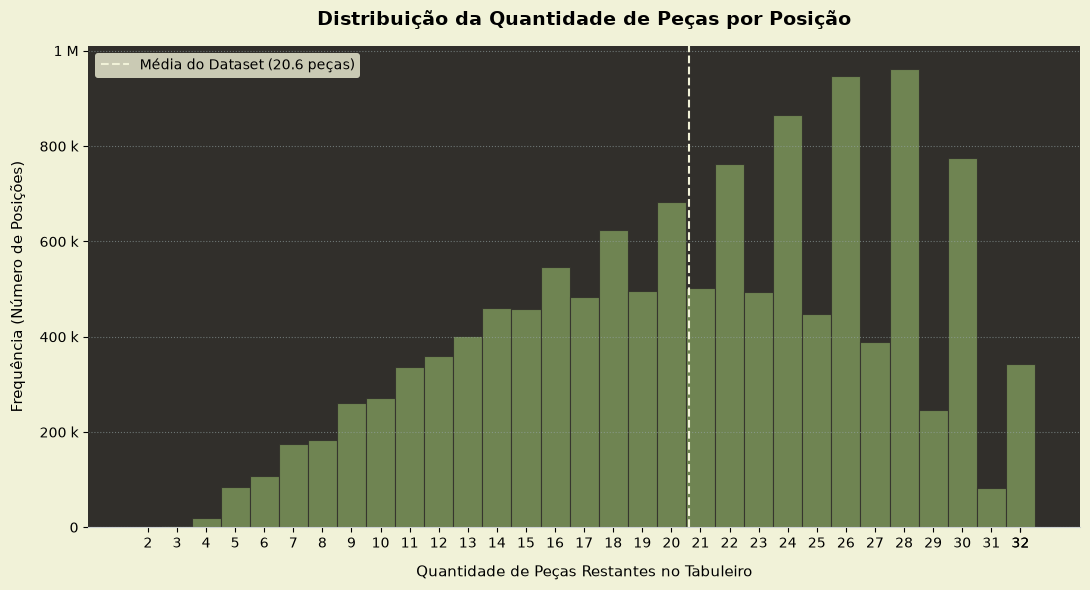

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))

COR_FUNDO_EXTERNO = '#F1F2D8' 
COR_FUNDO_INTERNO = '#312F2B' 

fig.patch.set_facecolor(COR_FUNDO_EXTERNO) 
ax.set_facecolor(COR_FUNDO_INTERNO)        

n, bins, patches = ax.hist(
    df['Quantidade_Pecas'], 
    bins=range(2, 34), 
    edgecolor=COR_FUNDO_INTERNO, 
    linewidth=0.8,
    alpha=0.85, 
    color='#7B9459',           
    align='left'
)

media_pecas = df['Quantidade_Pecas'].mean()

ax.axvline(
    media_pecas, 
    color='#F1F2D8', 
    linestyle='--', 
    linewidth=1.5, 
    label=f'Média do Dataset ({media_pecas:.1f} peças)' 
)

ax.legend(frameon=True, facecolor='#F1F2D8', edgecolor='none', fontsize=10)

ax.set_title('Distribuição da Quantidade de Peças por Posição', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Quantidade de Peças Restantes no Tabuleiro', fontsize=11, labelpad=10)
ax.set_ylabel('Frequência (Número de Posições)', fontsize=11, labelpad=10)

ax.set_xticks(list(range(2, 33, 1)) + [32])
ax.xaxis.set_tick_params(labelsize=10)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
ax.yaxis.set_tick_params(labelsize=10)

ax.grid(axis='x', visible=False)
ax.grid(axis='y', linestyle=':', alpha=0.6, color='#95a5a6') 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#ccd1d1') 

ax.legend(frameon=True, facecolor='#F1F2D8', edgecolor='none', fontsize=10)

plt.tight_layout()
plt.show()

O histograma mostra uma distribuição bem aceitável de quantidade de peças, mas o que salta de informação é a disparidade de posições com quantidade de peças pares, o que faz bastante sentido e até condiz com a realidade de um jogo, no início é comum que os adversários estejam com a mesma quantidade de peças.

#### 1.3 Split 

In [8]:
df_train, df_temp = train_test_split(df, test_size=0.20, random_state=seed)

df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=seed)

print(f"Quantidade de exemplos em Treino:   {len(df_train)}")
print(f"Quantidade de exemplos em Validação: {len(df_val)}")
print(f"Quantidade de exemplos em Teste:     {len(df_test)}")

Quantidade de exemplos em Treino:   10214304
Quantidade de exemplos em Validação: 1276788
Quantidade de exemplos em Teste:     1276789


### 2. Modelo

#### 2.1 Tensorização

Para que a CNN receba mais informação, vamos transformar nosso FEN em um tensor de 15 canais: os primeiros 12 funcionam como um mapeamento binário (one-hot) da posição das peças ($8 \times 8$), divididos igualmente entre brancas e pretas, enquanto as últimas 3 camadas adicionam o contexto dinâmico do jogo, onde o canal 12 indica a vez de jogar e os canais 13 e 14 representam os direitos de roque das brancas e das pretas, respectivamente. Essa estrutura entrega o tabuleiro mastigado para a rede, permitindo que os filtros convolucionais foquem direto no aprendizado de conceitos estratégicos.

In [9]:
class Dataset_tensor(Dataset):
    def __init__(self, dataframe):
        self.fens = dataframe['FEN'].values
        self.evals = dataframe['Evaluation_clean'].values

    def __len__(self):
        return len(self.fens)

    def FEN_para_tensor(self, fen):
        board = chess.Board(fen)
        
        tensor = np.zeros((15, 8, 8), dtype=np.float32)
        
        piece_to_channel = {
            (chess.PAWN, chess.WHITE): 0,
            (chess.KNIGHT, chess.WHITE): 1,
            (chess.BISHOP, chess.WHITE): 2,
            (chess.ROOK, chess.WHITE): 3,
            (chess.QUEEN, chess.WHITE): 4,
            (chess.KING, chess.WHITE): 5,
            (chess.PAWN, chess.BLACK): 6,
            (chess.KNIGHT, chess.BLACK): 7,
            (chess.BISHOP, chess.BLACK): 8,
            (chess.ROOK, chess.BLACK): 9,
            (chess.QUEEN, chess.BLACK): 10,
            (chess.KING, chess.BLACK): 11
        }
        
        # 1. Preenche os canais de 0 a 11 com a localização das peças
        for square, piece in board.piece_map().items():
            row = 7 - (square // 8)
            col = square % 8
            channel = piece_to_channel[(piece.piece_type, piece.color)]
            tensor[channel, row, col] = 1.0

        # 2. Canal 12: Vez de jogar 
        if board.turn == chess.WHITE:
            tensor[12, :, :] = 1.0

        # 3. Canal 13: Direitos de roque das Brancas
        if board.has_kingside_castling_rights(chess.WHITE) or board.has_queenside_castling_rights(chess.WHITE):
            tensor[13, :, :] = 1.0

        # 4. Canal 14: Direitos de roque das Pretas
        if board.has_kingside_castling_rights(chess.BLACK) or board.has_queenside_castling_rights(chess.BLACK):
            tensor[14, :, :] = 1.0

        return torch.tensor(tensor)

    def __getitem__(self, idx):
        fen = self.fens[idx]
        y = torch.tensor(self.evals[idx], dtype=torch.float32)
        X = self.FEN_para_tensor(fen)
        return X, y

train_dataset = Dataset_tensor(df_train)
val_dataset = Dataset_tensor(df_val)

batch_size = 256 
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Total de Batches em Treino: {len(train_loader)}")
print(f"Total de Batches em Validação: {len(val_loader)}")

Total de Batches em Treino: 39900
Total de Batches em Validação: 4988


#### 2.2 Resnet

In [14]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual  
        out = self.relu(out)
        return out

class ChessResNetEngine(nn.Module):
    def __init__(self, input_channels=15, num_res_blocks=4, hidden_channels=64):
        super(ChessResNetEngine, self).__init__()
        
        # Camada de entrada: transforma os 15 canais do nosso Dataset em canais ocultos (64)
        self.conv_init = nn.Conv2d(input_channels, hidden_channels, kernel_size=3, padding=1)
        self.bn_init = nn.BatchNorm2d(hidden_channels)
        self.relu = nn.ReLU()
        
        # Torre de Blocos Residuais para extração profunda de características táteis
        self.res_blocks = nn.Sequential(
            *[ResidualBlock(hidden_channels) for _ in range(num_res_blocks)]
        )
        
        # Camada de redução de canais antes de achatar para a Fully Connected
        self.conv_reducer = nn.Conv2d(hidden_channels, 32, kernel_size=1)
        self.bn_reducer = nn.BatchNorm2d(32)
        
        # Camadas totalmente conectadas para regressão (previsão do Centipawn)
        # 32 canais * mapa de tamanho 8 * 8 = 2048 neurônios de entrada
        self.fc1 = nn.Linear(32 * 8 * 8, 256)
        self.dropout = nn.Dropout(0.3)
        self.fc_out = nn.Linear(256, 1)

    def forward(self, x):
        # 1. Processamento Convolucional Inicial
        out = self.relu(self.bn_init(self.conv_init(x)))
        
        # 2. Passagem pela torre de blocos residuais (evita desaparecimento do gradiente)
        out = self.res_blocks(out)
        
        # 3. Redução de dimensionalidade espacial
        out = self.relu(self.bn_reducer(self.conv_reducer(out)))
        
        # 4. Achatamento (Flatten) para alimentar as camadas densas
        out = out.view(out.size(0), -1)
        
        # 5. Camadas lineares finais retornando um único escalar (a avaliação contínua)
        out = self.relu(self.fc1(out))
        out = self.dropout(out)
        out = self.fc_out(out)
        
        return out.squeeze(-1) # Remove a dimensão extra para alinhar com o vetor de alvos (y)

# Criando uma instância do modelo e movendo para a GPU (Cuda) se disponível
model = ChessResNetEngine(input_channels=15, num_res_blocks=4, hidden_channels=64).to(device)

print(f"\nModelo instanciado e alocado com sucesso no dispositivo: {device}")


Modelo instanciado e alocado com sucesso no dispositivo: cuda


#### 2.3 Treinamento


In [15]:
criterion = nn.HuberLoss(delta=150.0)  
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)


def train_one_epoch(model, loader, optimizer, criterion, device, epoch, total_epochs):
    model.train()
    running_loss = 0.0
    
    pbar = tqdm(loader, desc=f"Época [{epoch+1}/{total_epochs}] - Treinando", leave=False)
    
    for X_batch, y_batch in pbar:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
        
        pbar.set_postfix(batch_loss=f"{loss.item():.2f}")
        
    return running_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    
    pbar = tqdm(loader, desc="Avaliando", leave=False)
    
    for X_batch, y_batch in pbar:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        running_loss += loss.item() * X_batch.size(0)
        
    return running_loss / len(loader.dataset)

def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs=15):
    history = {'train_loss': [], 'val_loss': []}
    
    print("-" * 70)
    print(f"Iniciando o treinamento da Chess ResNet Engine por {epochs} Épocas")
    print("-" * 70)
    
    for epoch in range(epochs):

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, epoch, epochs)
        val_loss = evaluate(model, val_loader, criterion, device)
        
        scheduler.step(val_loss)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        
        lr_atual = optimizer.param_groups[0]['lr']
        print(f"✔ Época [{epoch+1:02d}/{epochs:02d}] concluída -> Train Loss: {train_loss:.2f} | Val Loss: {val_loss:.2f} | LR: {lr_atual:.6f}")
        
    print("-" * 70)
    print("Treinamento concluído com sucesso!")
    print("-" * 70)
    return history

##### 2.2.1 Loop de Treino

In [16]:
batch_size = 1024
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
criterion = nn.HuberLoss(delta=150.0)  
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

epochs = 2                                                                                    
history = fit(model, train_loader, val_loader, optimizer, criterion, device, epochs=epochs)


----------------------------------------------------------------------
Iniciando o treinamento da Chess ResNet Engine por 2 Épocas
----------------------------------------------------------------------


✔ Época [01/02] concluída -> Train Loss: 27557.97 | Val Loss: 25404.01 | LR: 0.001000


✔ Época [02/02] concluída -> Train Loss: 24998.56 | Val Loss: 59748.66 | LR: 0.001000
----------------------------------------------------------------------
Treinamento concluído com sucesso!
----------------------------------------------------------------------


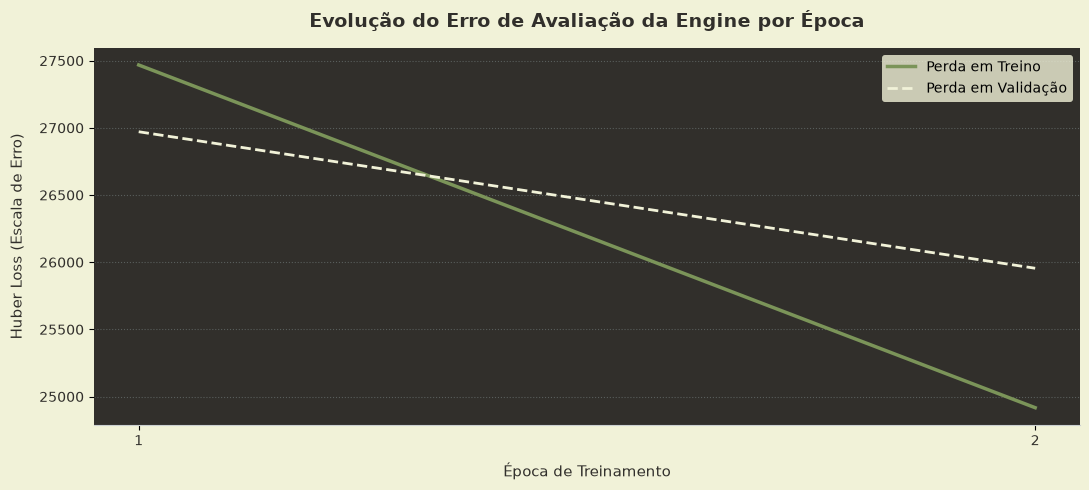

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))

COR_FUNDO_EXTERNO = '#F1F2D8' 
COR_FUNDO_INTERNO = '#312F2B' 

fig.patch.set_facecolor(COR_FUNDO_EXTERNO) 
ax.set_facecolor(COR_FUNDO_INTERNO)        

ax.plot(range(1, epochs + 1), history['train_loss'], label='Perda em Treino', color='#7B9459', linewidth=2.5)
ax.plot(range(1, epochs + 1), history['val_loss'], label='Perda em Validação', color='#F1F2D8', linewidth=2.0, linestyle='--')

ax.set_title('Evolução do Erro de Avaliação da Engine por Época', fontsize=14, fontweight='bold', pad=15, color=COR_FUNDO_INTERNO)
ax.set_xlabel('Época de Treinamento', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)
ax.set_ylabel('Huber Loss (Escala de Erro)', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)

ax.xaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.yaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.set_xticks(range(1, epochs + 1))

ax.grid(axis='x', visible=False)
ax.grid(axis='y', linestyle=':', alpha=0.4, color='#95a5a6') 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#ccd1d1') 

ax.legend(frameon=True, facecolor='#F1F2D8', edgecolor='none', fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()